<a href="https://colab.research.google.com/github/vicfior/Labirinto-com-Busca-Estocastica/blob/main/Labirinto_SA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BLOCO 1: Geração e Visualização do Labirinto


In [1]:
# importações

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
import math
import time
import colorsys
from flask import Flask
import json
import threading
from google.colab.output import eval_js
import logging
from google.colab import output

# semente aleatória
SEMENTE = int(time.time())
np.random.seed(SEMENTE)
print(f"Semente desta execução: {SEMENTE}")

Semente desta execução: 1779924609


In [2]:
# constantes do labirinto
# valores de cada célula na matriz
LIVRE   = 0
PAREDE  = 1
SAIDA   = 2
INICIO  = 3

TAMANHO_GRID = 100

# porcentagem de células que viram paredes
DENSIDADE_PAREDES = 0.40

# número de saídas
NUM_SAIDAS = 5

# número de robôs
NUM_ROBOS = 5

In [3]:
# geração do labirinto
def gerar_labirinto(tamanho, densidade, num_saidas, semente=None):
    """
    Gera um labirinto onde TODAS as saídas são alcançáveis
    por caminhos naturais — sem abrir corredores retos.

    Estratégia: tentativas repetidas (rejection sampling).
    Se após MAX_TENTATIVAS não conseguir, reduz a densidade
    automaticamente até conseguir.

    Complexidade: O(tentativas × N²)
    """
    if semente is not None:
        np.random.seed(semente)

    MAX_TENTATIVAS = 50

    for tentativa in range(MAX_TENTATIVAS):
        grid = np.zeros((tamanho, tamanho), dtype=int)

        centro_linha = tamanho // 2
        centro_col   = tamanho // 2
        inicio = (centro_linha, centro_col)

        saidas = _escolher_saidas(tamanho, num_saidas)
        for (l, c) in saidas:
            grid[l, c] = SAIDA

        _preencher_paredes(grid, inicio, saidas, densidade, tamanho)

        todas_conectadas = all(
            _tem_caminho(grid, inicio, saida, tamanho)
            for saida in saidas
        )

        if todas_conectadas:
            print(f"   Labirinto gerado em {tentativa + 1} tentativa(s) "
                  f"— densidade real: {np.sum(grid == PAREDE) / tamanho**2:.1%}")
            grid[inicio] = INICIO
            return grid, inicio, saidas

    densidade_reduzida = max(0.20, densidade - 0.05)
    print(f"   ⚠️ Não foi possível com {densidade:.0%} de paredes. "
          f"Tentando com {densidade_reduzida:.0%}...")
    return gerar_labirinto(tamanho, densidade_reduzida, num_saidas, semente=None)

def _escolher_saidas(tamanho, num_saidas):
    """
    Escolhe posições nas bordas do grid para as saídas,
    distribuídas de forma espalhada (uma por borda, aproximadamente).

    Complexidade: O(num_saidas) — constante na prática
    """
    bordas_possiveis = []
    meio = tamanho // 2
    quarto = tamanho // 4

    candidatos = [
        (0,          meio),
        (tamanho-1,  meio),
        (meio,       0),
        (meio,       tamanho-1),
        (quarto,     0),
        (quarto,     tamanho-1),
        (tamanho-1-quarto, 0),
        (tamanho-1-quarto, tamanho-1),
    ]

    np.random.shuffle(candidatos)
    return candidatos[:num_saidas]


def _preencher_paredes(grid, inicio, saidas, densidade, tamanho):
    """
    Preenche o grid com paredes aleatórias, respeitando início e saídas.

    Complexidade: O(N²)
    """
    celulas_protegidas = {inicio} | set(saidas)

    for l in range(tamanho):
        for c in range(tamanho):
            if (l, c) not in celulas_protegidas:
                # sorteio de Bernoulli
                if np.random.random() < densidade:
                    grid[l, c] = PAREDE


def _tem_caminho(grid, origem, destino, tamanho):
    """
    Verifica se existe caminho entre origem e destino usando Busca em Largura.
    BFS garante verificação completa em O(N²).

    Retorna True se existir caminho, False caso contrário.
    """
    visitado = set()
    fila = deque([origem])
    visitado.add(origem)

    # direções - cima, baixo, esquerda, direita
    direcoes = [(-1,0), (1,0), (0,-1), (0,1)]

    while fila:
        l, c = fila.popleft()

        if (l, c) == destino:
            return True

        for dl, dc in direcoes:
            nl, nc = l + dl, c + dc
            vizinho = (nl, nc)

            if (0 <= nl < tamanho and
                0 <= nc < tamanho and
                vizinho not in visitado and
                grid[nl, nc] != PAREDE):

                visitado.add(vizinho)
                fila.append(vizinho)

    return False

In [4]:
# visualização
COR_LIVRE   = '#F5F5F0'
COR_PAREDE  = '#2C3E50'
COR_SAIDA   = '#2ECC71'
COR_INICIO  = '#E74C3C'
COR_ROBO    = ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6']


def visualizar_labirinto(grid, inicio, saidas, titulo="Labirinto Inicial"):
    """
    Exibe o labirinto usando matplotlib com legenda clara.
    Compatível com Google Colab.

    Parâmetros:
        grid   (np.ndarray): matriz do labirinto
        inicio (tuple)     : posição de partida
        saidas (list)      : lista de posições das saídas
        titulo (str)       : título do gráfico
    """
    tamanho = grid.shape[0]

    imagem = np.ones((tamanho, tamanho, 3))

    for l in range(tamanho):
        for c in range(tamanho):
            if grid[l, c] == PAREDE:
                imagem[l, c] = _hex_para_rgb(COR_PAREDE)
            elif grid[l, c] == SAIDA:
                imagem[l, c] = _hex_para_rgb(COR_SAIDA)
            elif grid[l, c] == INICIO:
                imagem[l, c] = _hex_para_rgb(COR_INICIO)
            else:
                imagem[l, c] = _hex_para_rgb(COR_LIVRE)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(imagem, interpolation='nearest')

    ax.set_xticks(np.arange(-0.5, tamanho, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, tamanho, 1), minor=True)
    ax.grid(which='minor', color='#BDC3C7', linewidth=0.3)
    ax.tick_params(which='both', bottom=False, left=False,
                   labelbottom=False, labelleft=False)

    for i, (l, c) in enumerate(saidas):
        ax.text(c, l, f'S{i+1}', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')


    ax.text(inicio[1], inicio[0], '★', ha='center', va='center',
            fontsize=14, color='white')


    patches = [
        mpatches.Patch(color=COR_PAREDE, label='Parede'),
        mpatches.Patch(color=COR_LIVRE,  label='Caminho livre'),
        mpatches.Patch(color=COR_SAIDA,  label='Saída'),
        mpatches.Patch(color=COR_INICIO, label='Início (★)'),
    ]
    ax.legend(handles=patches, loc='upper right',
              bbox_to_anchor=(1.35, 1), fontsize=10)

    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()

    total_celulas  = tamanho * tamanho
    num_paredes    = np.sum(grid == PAREDE)
    num_livres     = np.sum(grid == LIVRE)
    densidade_real = num_paredes / total_celulas

    print(f"\n📊 Estatísticas do labirinto {tamanho}×{tamanho}:")
    print(f"   Total de células : {total_celulas}")
    print(f"   Células livres   : {num_livres}")
    print(f"   Paredes          : {num_paredes} ({densidade_real:.1%} do grid)")
    print(f"   Saídas           : {len(saidas)}")
    print(f"   Ponto de início  : {inicio}")
    print(f"   Posições saídas  : {saidas}")


def _hex_para_rgb(hex_cor):
    """Converte cor hexadecimal '#RRGGBB' para array RGB normalizado [0,1]."""
    hex_cor = hex_cor.lstrip('#')
    return [int(hex_cor[i:i+2], 16) / 255 for i in (0, 2, 4)]

   Labirinto gerado em 39 tentativa(s) — densidade real: 40.3%


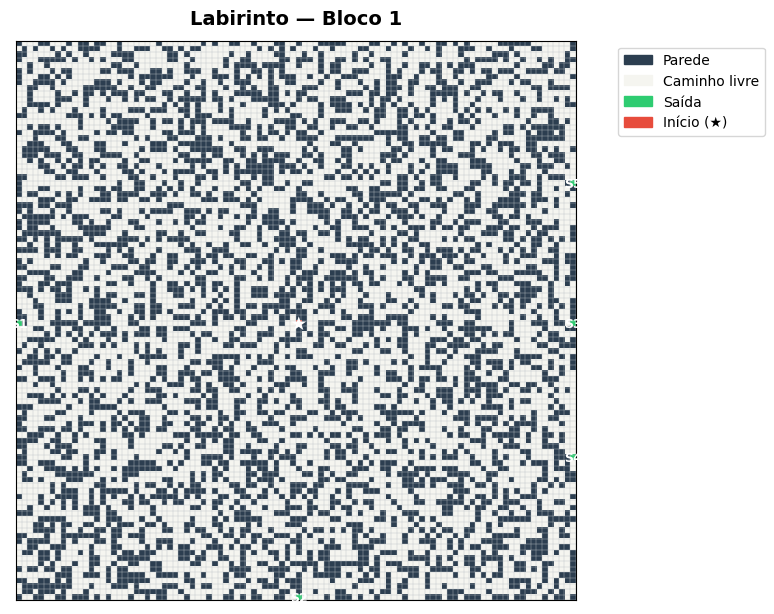


📊 Estatísticas do labirinto 100×100:
   Total de células : 10000
   Células livres   : 5965
   Paredes          : 4029 (40.3% do grid)
   Saídas           : 5
   Ponto de início  : (50, 50)
   Posições saídas  : [(50, 0), (99, 50), (50, 99), (74, 99), (25, 99)]

✅ Bloco 1 concluído!


In [5]:
grid, inicio, saidas = gerar_labirinto(
    tamanho    = TAMANHO_GRID,
    densidade  = DENSIDADE_PAREDES,
    num_saidas = NUM_SAIDAS,
    semente    = SEMENTE
)

visualizar_labirinto(grid, inicio, saidas, titulo="Labirinto — Bloco 1")

print("\n✅ Bloco 1 concluído!")

BLOCO 2: Representação da Solução e Operações de Perturbação





In [6]:
# constantes de direção
CIMA      = 0
BAIXO     = 1
ESQUERDA  = 2
DIREITA   = 3

# mapeamento direção → deslocamento (delta_linha, delta_coluna)
DELTA = {
    CIMA:     (-1,  0),
    BAIXO:    ( 1,  0),
    ESQUERDA: ( 0, -1),
    DIREITA:  ( 0,  1),
}

NOMES_DIRECAO = {CIMA: '↑', BAIXO: '↓', ESQUERDA: '←', DIREITA: '→'}

# N*N cobre o pior caso: percorrer todas as células do grid
COMPRIMENTO_MAX = TAMANHO_GRID * TAMANHO_GRID

In [7]:
# geração de solução inicial aleatória
def gerar_solucao_inicial(comprimento=None):
    """
    Gera uma sequência aleatória de movimentos como solução inicial.

    Esta é a "temperatura alta" do SA: começamos com um caminho
    completamente aleatório, sem nenhum conhecimento do labirinto.
    O SA vai refiná-lo iterativamente.

    Parâmetros:
        comprimento (int): número de movimentos na sequência.
                           Se None, usa COMPRIMENTO_MAX // 2.

    Retorna:
        solucao (np.ndarray): array de inteiros, cada um em {0,1,2,3}

    Complexidade:
        Tempo : O(comprimento) — gera cada movimento uma vez
        Espaço: O(comprimento) — armazena a sequência
    """
    if comprimento is None:
        comprimento = COMPRIMENTO_MAX // 2
    return np.random.randint(0, 4, size=comprimento)

In [8]:
# simulação do caminho
def simular_caminho(grid, inicio, solucao, tamanho):
    """
    Executa a sequência de movimentos no labirinto e retorna o
    caminho percorrido como lista de posições (linha, coluna).

    Regras de simulação:
    - Se o movimento leva a uma PAREDE → o robô fica no lugar
      (movimento inválido é ignorado, não penalizado aqui)
    - Se o movimento sai do grid → o robô fica no lugar
    - Se o robô chega a uma SAÍDA → para imediatamente (sucesso!)
    - Se esgota todos os movimentos sem achar saída → retorna onde parou

    Parâmetros:
        grid    (np.ndarray): matriz do labirinto
        inicio  (tuple)     : posição inicial (linha, coluna)
        solucao (np.ndarray): sequência de direções
        tamanho (int)       : dimensão N do grid

    Retorna:
        caminho      (list): lista de (linha, coluna) visitadas
        chegou_saida (bool): True se o robô alcançou alguma saída
        passos_validos(int): quantos movimentos efetivamente avançaram

    Complexidade:
        Tempo : O(|solucao|) — processa cada movimento uma vez
        Espaço: O(|solucao|) — armazena o caminho no pior caso
    """
    l, c = inicio
    caminho = [(l, c)]
    passos_validos = 0

    for direcao in solucao:
        dl, dc = DELTA[direcao]
        nl = l + dl
        nc = c + dc

        dentro_do_grid = (0 <= nl < tamanho and 0 <= nc < tamanho)
        if not dentro_do_grid:
            continue

        if grid[nl, nc] == PAREDE:
            continue

        l, c = nl, nc
        caminho.append((l, c))
        passos_validos += 1

        if grid[l, c] == SAIDA:
            return caminho, True, passos_validos

    return caminho, False, passos_validos

In [9]:
# operações de perturbação
def perturbar_solucao(solucao, intensidade=1):
    """
    Gera uma solução vizinha aplicando perturbações aleatórias.

    O SA precisa explorar soluções próximas da atual — nem iguais
    (nenhum progresso), nem completamente diferentes (perde contexto).

    Três tipos de perturbação, escolhidos aleatoriamente:
    ┌─────────────────┬──────────────────────────────────────────────┐
    │ Tipo            │ O que faz                                    │
    ├─────────────────┼──────────────────────────────────────────────┤
    │ SUBSTITUIÇÃO    │ Troca um movimento por outro aleatório       │
    │ INVERSÃO        │ Inverte a ordem de um trecho do caminho      │
    │ INSERÇÃO/REMOÇÃO│ Adiciona ou remove um movimento aleatório    │
    └─────────────────┴──────────────────────────────────────────────┘

    A SUBSTITUIÇÃO é a perturbação mais comum e menor (exploração local).
    A INVERSÃO é mais agressiva (útil para escapar de mínimos locais).
    A INSERÇÃO/REMOÇÃO ajusta o comprimento — dá flexibilidade ao SA.

    Parâmetros:
        solucao    (np.ndarray): solução atual
        intensidade (int)      : quantas perturbações aplicar (default=1)

    Retorna:
        nova_solucao (np.ndarray): cópia perturbada da solução original

    Complexidade:
        Tempo : O(intensidade + |trecho_invertido|) ≈ O(N) no pior caso
        Espaço: O(|solucao|) — cópia da solução
    """
    nova = solucao.copy()

    for _ in range(intensidade):
        tipo = np.random.randint(0, 3)

        if tipo == 0:
            pos = np.random.randint(0, len(nova))
            direcao_atual = nova[pos]
            direcoes_possiveis = [d for d in range(4) if d != direcao_atual]
            nova[pos] = np.random.choice(direcoes_possiveis)

        elif tipo == 1:
            if len(nova) < 2:
                continue
            i = np.random.randint(0, len(nova) - 1)
            j = np.random.randint(i + 1, min(i + TAMANHO_GRID, len(nova)))
            nova[i:j] = nova[i:j][::-1]

        else:
            if np.random.random() < 0.5 and len(nova) < COMPRIMENTO_MAX:
                pos = np.random.randint(0, len(nova) + 1)
                novo_mov = np.random.randint(0, 4)
                nova = np.insert(nova, pos, novo_mov)
            elif len(nova) > 1:
                pos = np.random.randint(0, len(nova))
                nova = np.delete(nova, pos)

    return nova

In [10]:
 # imprimir caminho
def descrever_solucao(solucao, max_exibir=20):
    """
    Exibe os primeiros movimentos de uma solução de forma legível.
    Útil para depurar e entender o que o SA está gerando.

    Parâmetros:
        solucao    (np.ndarray): sequência de direções
        max_exibir (int)       : quantos movimentos mostrar
    """
    simbolos = [NOMES_DIRECAO[d] for d in solucao[:max_exibir]]
    reticencias = '...' if len(solucao) > max_exibir else ''
    print(f"Solução ({len(solucao)} movimentos): {' '.join(simbolos)} {reticencias}")


def visualizar_caminho(grid, caminho, inicio, saidas, titulo="Caminho do Robô"):
    """
    Visualiza o caminho percorrido pelo robô sobre o labirinto.

    Parâmetros:
        grid    (np.ndarray): matriz do labirinto
        caminho (list)      : lista de (linha, coluna) visitadas
        inicio  (tuple)     : posição de partida
        saidas  (list)      : posições das saídas
        titulo  (str)       : título do gráfico
    """
    tamanho = grid.shape[0]
    imagem = np.ones((tamanho, tamanho, 3))

    for l in range(tamanho):
        for c in range(tamanho):
            if grid[l, c] == PAREDE:
                imagem[l, c] = _hex_para_rgb(COR_PAREDE)
            elif grid[l, c] == SAIDA:
                imagem[l, c] = _hex_para_rgb(COR_SAIDA)
            elif grid[l, c] == INICIO:
                imagem[l, c] = _hex_para_rgb(COR_INICIO)
            else:
                imagem[l, c] = _hex_para_rgb(COR_LIVRE)

    n_passos = len(caminho)
    for i, (l, c) in enumerate(caminho):
        if (l, c) == inicio or grid[l, c] == SAIDA:
            continue
        intensidade = i / max(n_passos - 1, 1)
        r = 0.53 * (1 - intensidade) + 0.10 * intensidade
        g = 0.81 * (1 - intensidade) + 0.40 * intensidade
        b = 0.98 * (1 - intensidade) + 0.80 * intensidade
        imagem[l, c] = [r, g, b]

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(imagem, interpolation='nearest')

    ax.set_xticks(np.arange(-0.5, tamanho, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, tamanho, 1), minor=True)
    ax.grid(which='minor', color='#BDC3C7', linewidth=0.3)
    ax.tick_params(which='both', bottom=False, left=False,
                   labelbottom=False, labelleft=False)

    # marcar início e saídas
    ax.text(inicio[1], inicio[0], '★', ha='center', va='center',
            fontsize=14, color='white')
    for i, (l, c) in enumerate(saidas):
        ax.text(c, l, f'S{i+1}', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')

    if caminho:
        pos_final = caminho[-1]
        ax.plot(pos_final[1], pos_final[0], 'o',
                color='#E74C3C', markersize=10, zorder=5)

    patches = [
        mpatches.Patch(color=COR_PAREDE,   label='Parede'),
        mpatches.Patch(color='#87CEEB',    label='Caminho (início)'),
        mpatches.Patch(color='#1A66CC',    label='Caminho (fim)'),
        mpatches.Patch(color=COR_SAIDA,    label='Saída'),
        mpatches.Patch(color=COR_INICIO,   label='Início (★)'),
    ]
    ax.legend(handles=patches, loc='upper right',
              bbox_to_anchor=(1.38, 1), fontsize=9)
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()

  BLOCO 2 — Teste da Representação da Solução

 Teste 1: Solução inicial aleatória
Solução (5000 movimentos): ↓ ← ↓ ↓ ↓ ↑ ← ↓ ↓ ↓ → ← ↓ ← → ↓ ↑ ↑ ← → ...

 Teste 2: Simulação do caminho no labirinto
   Posições visitadas : 3094
   Passos válidos     : 3093
   Chegou à saída?    : ❌ NÃO (esperado — caminho aleatório)
   Posição final      : (68, 53)

 Teste 3: Perturbação da solução
Solução (5000 movimentos): ↓ ← ↓ ↓ ↓ ↑ ← ↓ ↓ ↓ → ← ↓ ← → ↓ ↑ ↑ ← → ...
   Tamanho original   : 5000
   Tamanho perturbado : 5000
   Posições diferentes: 1

📌 Visualizando caminho da solução inicial aleatória...


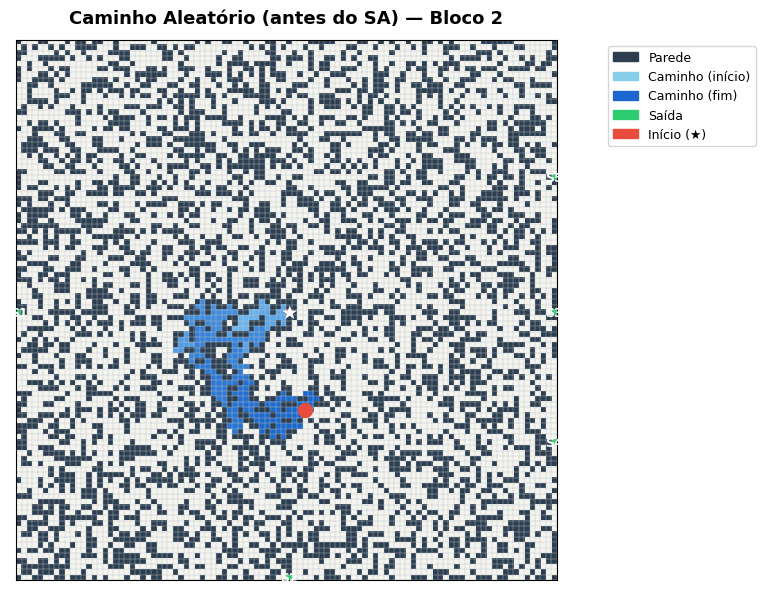

In [11]:
print("=" * 55)
print("  BLOCO 2 — Teste da Representação da Solução")
print("=" * 55)

print("\n Teste 1: Solução inicial aleatória")
solucao_inicial = gerar_solucao_inicial()
descrever_solucao(solucao_inicial)

print("\n Teste 2: Simulação do caminho no labirinto")
caminho, chegou, passos = simular_caminho(
    grid, inicio, solucao_inicial, TAMANHO_GRID
)
print(f"   Posições visitadas : {len(caminho)}")
print(f"   Passos válidos     : {passos}")
print(f"   Chegou à saída?    : {'✅ SIM' if chegou else '❌ NÃO (esperado — caminho aleatório)'}")
print(f"   Posição final      : {caminho[-1]}")

print("\n Teste 3: Perturbação da solução")
solucao_perturbada = perturbar_solucao(solucao_inicial, intensidade=1)
descrever_solucao(solucao_perturbada)
print(f"   Tamanho original   : {len(solucao_inicial)}")
print(f"   Tamanho perturbado : {len(solucao_perturbada)}")
diferencas = np.sum(
    solucao_inicial[:min(len(solucao_inicial), len(solucao_perturbada))]
    != solucao_perturbada[:min(len(solucao_inicial), len(solucao_perturbada))]
)
print(f"   Posições diferentes: {diferencas}")
print("\n📌 Visualizando caminho da solução inicial aleatória...")
visualizar_caminho(
    grid, caminho, inicio, saidas,
    titulo="Caminho Aleatório (antes do SA) — Bloco 2"
)

BLOCO 3: Função Objetivo (o que o SA tenta minimizar)

In [12]:
# parâmetros da função objetivo
PENALIDADE_SEM_SAIDA = 10_000

# Peso da distância até a saída mais próxima (quando não chegou)
PESO_DISTANCIA = 50

# Peso do número de passos (quando chegou)
PESO_PASSOS = 1

# Bônus por chegar — recompensa adicional subtraída do custo
BONUS_CHEGADA = 500

In [13]:
# função de distância de Manhattan

def distancia_manhattan(pos_a, pos_b):
    """
    Calcula a Distância de Manhattan entre duas posições do grid.

    Em labirintos com movimentos ortogonais (↑↓←→), a distância
    de Manhattan é a estimativa mais precisa do caminho mínimo
    IGNORANDO paredes — a mesma heurística usada pelo algoritmo A*.

    Fórmula: d(A,B) = |linha_A - linha_B| + |coluna_A - coluna_B|

    Complexidade: O(1) — operação aritmética constante
    """
    return abs(pos_a[0] - pos_b[0]) + abs(pos_a[1] - pos_b[1])


def distancia_saida_mais_proxima(posicao, saidas):
    """
    Retorna a menor distância de Manhattan entre a posição atual
    e qualquer uma das saídas disponíveis.

    O robô não precisa ir para uma saída específica — pode ir para
    qualquer uma. Logo, o SA minimiza a distância até a MAIS PRÓXIMA.

    Complexidade: O(|saidas|) — constante na prática (4 saídas)
    """
    return min(distancia_manhattan(posicao, saida) for saida in saidas)

In [14]:
# função objetivo principal

def calcular_custo(grid, inicio, solucao, saidas, tamanho):
    """
    Calcula o custo total de uma solução — o valor que o SA minimiza.

    A função tem dois regimes completamente separados:

    REGIME 1 — Robô NÃO chegou à saída:
    ┌─────────────────────────────────────────────────────────────────┐
    │ custo = PENALIDADE_SEM_SAIDA + PESO_DISTANCIA × dist_manhattan │
    └─────────────────────────────────────────────────────────────────┘
    A penalidade garante que este regime é SEMPRE pior que o Regime 2.
    A distância cria um gradiente: robôs mais perto da saída têm
    custo menor, guiando o SA na direção correta.

    REGIME 2 — Robô chegou à saída:
    ┌─────────────────────────────────────────────────────────────────┐
    │ custo = PESO_PASSOS × passos_validos - BONUS_CHEGADA           │
    └─────────────────────────────────────────────────────────────────┘
    Aqui o SA otimiza a EFICIÊNCIA: minimiza o número de passos.
    O bônus negativo garante separação clara entre os dois regimes.

    Parâmetros:
        grid    (np.ndarray): matriz do labirinto
        inicio  (tuple)     : posição de partida
        solucao (np.ndarray): sequência de movimentos a avaliar
        saidas  (list)      : posições das saídas
        tamanho (int)       : dimensão N do grid

    Retorna:
        custo        (float): valor a minimizar (menor = melhor)
        chegou       (bool) : se o robô alcançou alguma saída
        caminho      (list) : trajeto percorrido
        passos       (int)  : movimentos válidos realizados

    Complexidade:
        Tempo : O(|solucao|) dominado pela simulação do caminho
        Espaço: O(|solucao|) para armazenar o caminho
    """
    caminho, chegou, passos = simular_caminho(
        grid, inicio, solucao, tamanho
    )

    posicao_final = caminho[-1]

    if not chegou:
        dist = distancia_saida_mais_proxima(posicao_final, saidas)
        custo = PENALIDADE_SEM_SAIDA + PESO_DISTANCIA * dist

    else:
        custo = PESO_PASSOS * passos - BONUS_CHEGADA

    return custo, chegou, caminho, passos

In [15]:
# função de progresso para as barras
def calcular_progresso(custo):
    """
    Converte o custo em um valor de PROGRESSO entre 0.0 e 1.0
    para exibir nas barras de aprendizado da visualização.

    Lógica de normalização:
    - Custo máximo possível ≈ PENALIDADE_SEM_SAIDA + PESO_DISTANCIA × 40
      (pior caso: não chegou + distância máxima no grid 21×21)
    - Custo mínimo possível ≈ PESO_PASSOS × 1 - BONUS_CHEGADA
      (melhor caso: chegou em 1 passo — impossível na prática, mas é o piso)

    Fórmula: progresso = 1 - (custo - custo_min) / (custo_max - custo_min)
    Clampado em [0, 1] para robustez.

    Complexidade: O(1)
    """
    custo_max = PENALIDADE_SEM_SAIDA + PESO_DISTANCIA * (2 * TAMANHO_GRID)
    custo_min = PESO_PASSOS * 1 - BONUS_CHEGADA

    progresso = 1.0 - (custo - custo_min) / (custo_max - custo_min)

    return max(0.0, min(1.0, progresso))

  BLOCO 3 — Teste da Função Objetivo

📌 Teste 1: Custo de solução aleatória (sem saída esperada)
   Chegou à saída?   : ❌ NÃO
   Posição final     : (50, 43)
   Dist. à saída +próx: 43 (Manhattan)
   Custo total       : 12,150
   Progresso (barra) : 38.3%

📌 Teste 2: Solução que chega na saída (simulada)
   Chegou à saída?   : ✅ SIM
   Passos válidos    : 78
   Custo total       : -422
   Progresso (barra) : 99.6%

📌 Teste 3: Comparação clara dos dois regimes
   Solução                        Custo    Progresso   Chegou
   -------------------------------------------------------
   Aleatória (sem saída)         12,150       38.3%        ❌
   BFS / ótima (com saída)         -422       99.6%        ✅

   ➡ Diferença de custo: 12,572 pontos
   ➡ O SA tem sinal claro para preferir soluções que chegam à saída.


/tmp/ipykernel_30908/2026822638.py:115: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_30908/2026822638.py:115: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


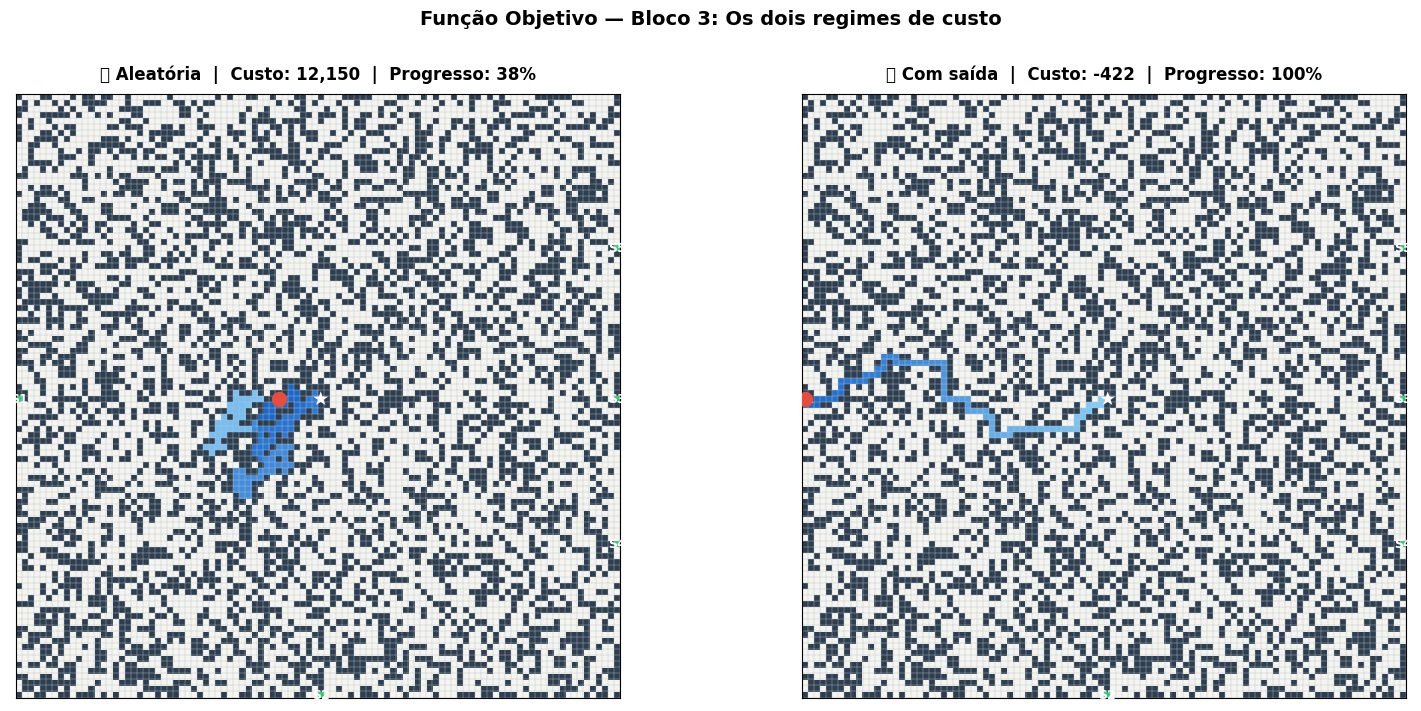

In [16]:
# execução e testes do bloco 3

print("=" * 60)
print("  BLOCO 3 — Teste da Função Objetivo")
print("=" * 60)

print("\n📌 Teste 1: Custo de solução aleatória (sem saída esperada)")
np.random.seed(SEMENTE)
sol_aleatoria = gerar_solucao_inicial()
custo, chegou, caminho, passos = calcular_custo(
    grid, inicio, sol_aleatoria, saidas, TAMANHO_GRID
)
progresso = calcular_progresso(custo)

print(f"   Chegou à saída?   : {'✅ SIM' if chegou else '❌ NÃO'}")
print(f"   Posição final     : {caminho[-1]}")
dist_final = distancia_saida_mais_proxima(caminho[-1], saidas)
print(f"   Dist. à saída +próx: {dist_final} (Manhattan)")
print(f"   Custo total       : {custo:,.0f}")
print(f"   Progresso (barra) : {progresso:.1%}")
print("\n📌 Teste 2: Solução que chega na saída (simulada)")

def _caminho_bfs(grid, inicio, saida, tamanho):
    """BFS auxiliar de teste — encontra caminho real para validação."""
    pai = {inicio: None}
    fila = deque([inicio])
    direcoes = [(-1,0),(1,0),(0,-1),(0,1)]
    mapa_dir = {(-1,0): CIMA,(1,0): BAIXO,(0,-1): ESQUERDA,(0,1): DIREITA}
    while fila:
        l, c = fila.popleft()
        if (l,c) == saida:
            break
        for dl,dc in direcoes:
            nl,nc = l+dl,c+dc
            if (0<=nl<tamanho and 0<=nc<tamanho
                    and (nl,nc) not in pai
                    and grid[nl,nc] != PAREDE):
                pai[(nl,nc)] = ((l,c),(dl,dc))
                fila.append((nl,nc))
    movs = []
    pos = saida
    while pai.get(pos) is not None:
        pos_ant, (dl,dc) = pai[pos]
        movs.append(mapa_dir[(dl,dc)])
        pos = pos_ant
    return np.array(movs[::-1])

sol_otima = _caminho_bfs(grid, inicio, saidas[0], TAMANHO_GRID)
custo_otimo, chegou_otimo, caminho_otimo, passos_otimos = calcular_custo(
    grid, inicio, sol_otima, saidas, TAMANHO_GRID
)
progresso_otimo = calcular_progresso(custo_otimo)

print(f"   Chegou à saída?   : {'✅ SIM' if chegou_otimo else '❌ NÃO'}")
print(f"   Passos válidos    : {passos_otimos}")
print(f"   Custo total       : {custo_otimo:,.0f}")
print(f"   Progresso (barra) : {progresso_otimo:.1%}")

print("\n📌 Teste 3: Comparação clara dos dois regimes")
print(f"   {'Solução':<25} {'Custo':>10} {'Progresso':>12} {'Chegou':>8}")
print(f"   {'-'*55}")
print(f"   {'Aleatória (sem saída)':<25} {custo:>10,.0f} "
      f"{progresso:>11.1%} {'❌':>8}")
print(f"   {'BFS / ótima (com saída)':<25} {custo_otimo:>10,.0f} "
      f"{progresso_otimo:>11.1%} {'✅':>8}")
print(f"\n   ➡ Diferença de custo: {custo - custo_otimo:,.0f} pontos")
print(f"   ➡ O SA tem sinal claro para preferir soluções que chegam à saída.")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def _desenhar_no_ax(ax, grid, caminho, inicio, saidas, titulo, tamanho):
    imagem = np.ones((tamanho, tamanho, 3))
    for l in range(tamanho):
        for c in range(tamanho):
            if grid[l, c] == PAREDE:
                imagem[l, c] = _hex_para_rgb(COR_PAREDE)
            elif grid[l, c] == SAIDA:
                imagem[l, c] = _hex_para_rgb(COR_SAIDA)
            elif grid[l, c] == INICIO:
                imagem[l, c] = _hex_para_rgb(COR_INICIO)
            else:
                imagem[l, c] = _hex_para_rgb(COR_LIVRE)
    n = len(caminho)
    for i, (l, c) in enumerate(caminho):
        if (l,c) == inicio or grid[l,c] in (SAIDA, INICIO):
            continue
        t = i / max(n-1, 1)
        imagem[l, c] = [0.53*(1-t)+0.10*t, 0.81*(1-t)+0.40*t, 0.98*(1-t)+0.80*t]
    ax.imshow(imagem, interpolation='nearest')
    ax.set_xticks(np.arange(-0.5, tamanho, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, tamanho, 1), minor=True)
    ax.grid(which='minor', color='#BDC3C7', linewidth=0.3)
    ax.tick_params(which='both', bottom=False, left=False,
                   labelbottom=False, labelleft=False)
    ax.text(inicio[1], inicio[0], '★', ha='center', va='center',
            fontsize=14, color='white')
    for i2, (l2,c2) in enumerate(saidas):
        ax.text(c2, l2, f'S{i2+1}', ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')
    if caminho:
        pf = caminho[-1]
        ax.plot(pf[1], pf[0], 'o', color='#E74C3C', markersize=10, zorder=5)
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)

_desenhar_no_ax(axes[0], grid, caminho, inicio, saidas,
    f"❌ Aleatória  |  Custo: {custo:,.0f}  |  Progresso: {progresso:.0%}",
    TAMANHO_GRID)

_desenhar_no_ax(axes[1], grid, caminho_otimo, inicio, saidas,
    f"✅ Com saída  |  Custo: {custo_otimo:,.0f}  |  Progresso: {progresso_otimo:.0%}",
    TAMANHO_GRID)

plt.suptitle("Função Objetivo — Bloco 3: Os dois regimes de custo",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

BLOCO 4: Núcleo do Simulated Annealing (motor de um robô)

In [17]:
# parâmetros do SA
# Temperaturas muito altas → explora muito, demora mais a convergir
# Temperaturas muito baixas → converge rápido, mas fica preso em mínimos locais

TEMPERATURA_INICIAL_ROBOS = [500.0, 300.0, 150.0, 80.0]

# taxa de resfriamento — fator multiplicativo aplicado a cada iteração
TAXA_RESFRIAMENTO = 0.995

# temperatura mínima — abaixo disso o SA para de aceitar soluções piores
TEMPERATURA_MINIMA = 0.1

# complexidade do SA: O(MAX_ITERACOES × |solucao|)
MAX_ITERACOES = 5000

# 1 = perturbação mínima (muda pouco a cada passo)
INTENSIDADE_PERTURBACAO = 3

In [18]:
# critério de aceitação de Metropolis

def criterio_metropolis(custo_atual, custo_novo, temperatura):
    """
    Decide se o SA aceita ou rejeita uma solução vizinha.
    Isto é o que diferencia o SA de uma busca gulosa simples.

    Regras:
    ┌──────────────────────────────────────────────────────────────┐
    │ SE custo_novo < custo_atual (solução melhor):               │
    │     → aceita SEMPRE (prob = 1.0)                            │
    │                                                              │
    │ SE custo_novo ≥ custo_atual (solução pior ou igual):        │
    │     → aceita com probabilidade = e^(-Δ/T)                   │
    │       onde Δ = custo_novo - custo_atual                     │
    │             T = temperatura atual                            │
    └──────────────────────────────────────────────────────────────┘

    Por que aceitar soluções piores:
    → Para escapar de MÍNIMOS LOCAIS. Um algoritmo puramente guloso
      (hill climbing) fica preso na primeira "bacia" que encontra.
      O SA aceita subidas temporárias para explorar outras regiões
      do espaço de busca — a mesma intuição do recozimento do metal.

    Como a temperatura controla isso:
    → Temperatura ALTA: e^(-Δ/T) ≈ 1 → aceita quase tudo (exploração)
    → Temperatura BAIXA: e^(-Δ/T) ≈ 0 → aceita quase nada (explotação)

    Exemplo numérico com Δ=100:
        T=500 → prob = e^(-100/500) = e^(-0.2) ≈ 0.82  (82% de aceite)
        T=100 → prob = e^(-100/100) = e^(-1.0) ≈ 0.37  (37% de aceite)
        T=10  → prob = e^(-100/10)  = e^(-10)  ≈ 0.00  (0% de aceite)

    Parâmetros:
        custo_atual (float): custo da solução corrente
        custo_novo  (float): custo da solução vizinha candidata
        temperatura (float): temperatura atual do SA

    Retorna:
        aceitar (bool): True se deve aceitar a nova solução

    Complexidade: O(1)
    """
    delta = custo_novo - custo_atual

    if delta < 0:
        return True

    if temperatura <= 0:
        return False

    # Probabilidade de Metropolis: e^(-Δ/T)
    probabilidade = math.exp(-delta / temperatura)
    return np.random.random() < probabilidade

In [19]:
def executar_sa(grid, inicio, saidas, tamanho,
                temperatura_inicial=300.0,
                taxa_resfriamento=None,
                temperatura_minima=None,
                max_iteracoes=None,
                intensidade=None,
                id_robo=0):

    if taxa_resfriamento is None:
        taxa_resfriamento = 0.995
    if temperatura_minima is None:
        temperatura_minima = 0.1
    if max_iteracoes is None:
        max_iteracoes = 3000
    if intensidade is None:
        intensidade = 1

    solucao_atual = gerar_solucao_inicial()
    custo_atual, chegou_atual, caminho_atual, _ = calcular_custo(
        grid, inicio, solucao_atual, saidas, tamanho
    )

    melhor_solucao = solucao_atual.copy()
    melhor_custo   = custo_atual
    melhor_caminho = caminho_atual
    chegou_melhor  = chegou_atual
    temperatura      = temperatura_inicial
    iteracao_sucesso = None

    historico = {
        'custos'            : [],
        'progressos'        : [],
        'temperaturas'      : [],
        'chegou'            : [],
        'melhor_caminho'    : caminho_atual,
        'melhor_custo'      : melhor_custo,
        'chegou_final'      : chegou_melhor,
        'iteracao_sucesso'  : None,
        'id_robo'           : id_robo,
        'temperatura_inicial': temperatura_inicial,
    }

    for iteracao in range(max_iteracoes):
        if temperatura < temperatura_minima:
            break

        candidato = perturbar_solucao(solucao_atual, intensidade)
        custo_cand, chegou_cand, caminho_cand, _ = calcular_custo(
            grid, inicio, candidato, saidas, tamanho
        )

        if criterio_metropolis(custo_atual, custo_cand, temperatura):
            solucao_atual = candidato
            custo_atual   = custo_cand
            chegou_atual  = chegou_cand
            caminho_atual = caminho_cand

        if custo_atual < melhor_custo:
            melhor_solucao = solucao_atual.copy()
            melhor_custo   = custo_atual
            melhor_caminho = caminho_atual
            chegou_melhor  = chegou_atual
            if chegou_melhor and iteracao_sucesso is None:
                iteracao_sucesso = iteracao

        temperatura *= taxa_resfriamento

        progresso = calcular_progresso(melhor_custo)
        historico['custos'].append(melhor_custo)
        historico['progressos'].append(progresso)
        historico['temperaturas'].append(temperatura)
        historico['chegou'].append(chegou_melhor)

    historico['melhor_caminho']   = melhor_caminho
    historico['melhor_custo']     = melhor_custo
    historico['chegou_final']     = chegou_melhor
    historico['iteracao_sucesso'] = iteracao_sucesso

    return historico

  BLOCO 4 — Teste do Simulated Annealing (1 robô)

⚙️  Parâmetros:
   Temperatura inicial : 500.0
   Taxa de resfriamento: 0.995
   Temperatura mínima  : 0.1
   Máximo de iterações : 3000

🤖 Rodando SA para o Robô 0...

📊 Resultados:
   Iterações rodadas     : 1700
   Chegou à saída?       : ✅ SIM
   1ª iteração de sucesso: #544
   Melhor custo          : 2,027.0
   Progresso final       : 87.7%
   Temperatura final     : 0.0996


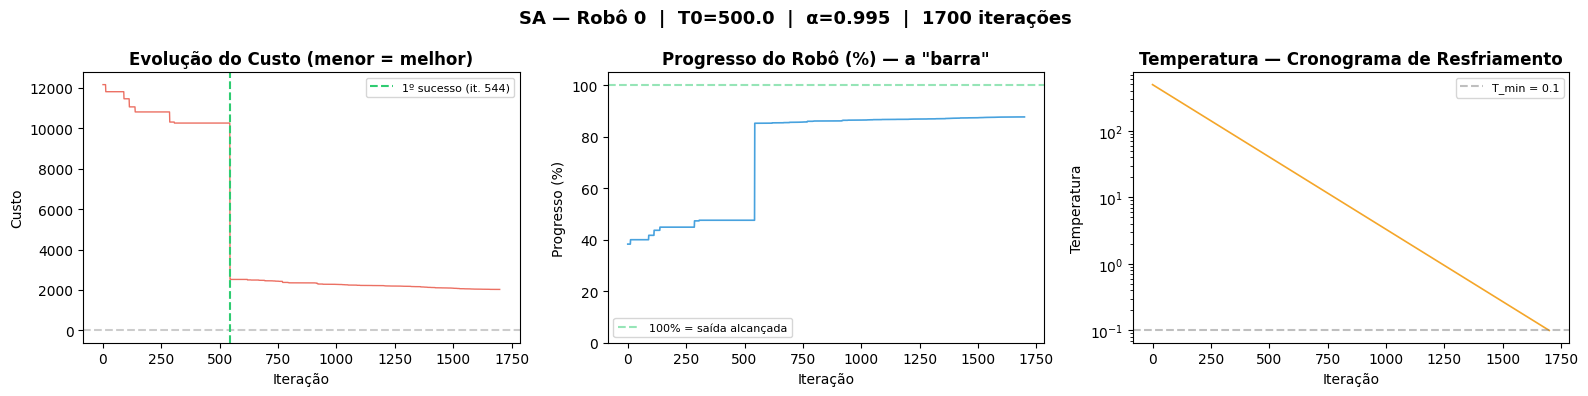

/tmp/ipykernel_30908/2950919577.py:82: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


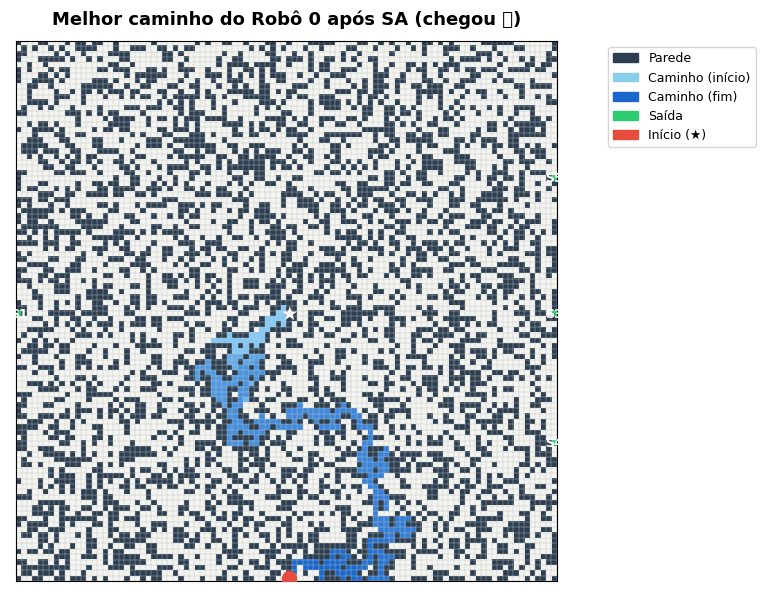

In [20]:
# testes do bloco 4
temperatura_inicial_teste = 500.0
taxa_resfriamento_teste   = 0.995
temperatura_minima_teste  = 0.1
max_iteracoes_teste       = 3000

print("=" * 60)
print("  BLOCO 4 — Teste do Simulated Annealing (1 robô)")
print("=" * 60)

print(f"\n⚙️  Parâmetros:")
print(f"   Temperatura inicial : {temperatura_inicial_teste}")
print(f"   Taxa de resfriamento: {taxa_resfriamento_teste}")
print(f"   Temperatura mínima  : {temperatura_minima_teste}")
print(f"   Máximo de iterações : {max_iteracoes_teste}")

print(f"\n🤖 Rodando SA para o Robô 0...")

np.random.seed(SEMENTE)
historico_teste = executar_sa(
    grid, inicio, saidas, TAMANHO_GRID,
    temperatura_inicial  = temperatura_inicial_teste,
    taxa_resfriamento    = taxa_resfriamento_teste,
    temperatura_minima   = temperatura_minima_teste,
    max_iteracoes        = max_iteracoes_teste,
    id_robo = 0
)

iteracoes_rodadas = len(historico_teste['custos'])
print(f"\n📊 Resultados:")
print(f"   Iterações rodadas     : {iteracoes_rodadas}")
print(f"   Chegou à saída?       : {'✅ SIM' if historico_teste['chegou_final'] else '❌ NÃO'}")
if historico_teste['iteracao_sucesso'] is not None:
    print(f"   1ª iteração de sucesso: #{historico_teste['iteracao_sucesso']}")
print(f"   Melhor custo          : {historico_teste['melhor_custo']:,.1f}")
print(f"   Progresso final       : {historico_teste['progressos'][-1]:.1%}")
print(f"   Temperatura final     : {historico_teste['temperaturas'][-1]:.4f}")

# ── Gráficos de aprendizado
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
iteracoes = range(len(historico_teste['custos']))

axes[0].plot(iteracoes, historico_teste['custos'],
             color='#E74C3C', linewidth=1.0, alpha=0.8)
axes[0].set_title('Evolução do Custo (menor = melhor)', fontweight='bold')
axes[0].set_xlabel('Iteração')
axes[0].set_ylabel('Custo')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.4)
if historico_teste['iteracao_sucesso']:
    axes[0].axvline(x=historico_teste['iteracao_sucesso'],
                    color='#2ECC71', linestyle='--', linewidth=1.5,
                    label=f"1º sucesso (it. {historico_teste['iteracao_sucesso']})")
    axes[0].legend(fontsize=8)

axes[1].plot(iteracoes, [p * 100 for p in historico_teste['progressos']],
             color='#3498DB', linewidth=1.2, alpha=0.9)
axes[1].set_title('Progresso do Robô (%) — a "barra"', fontweight='bold')
axes[1].set_xlabel('Iteração')
axes[1].set_ylabel('Progresso (%)')
axes[1].set_ylim(0, 105)
axes[1].axhline(y=100, color='#2ECC71', linestyle='--', alpha=0.5,
                label='100% = saída alcançada')
axes[1].legend(fontsize=8)

axes[2].plot(iteracoes, historico_teste['temperaturas'],
             color='#F39C12', linewidth=1.2, alpha=0.9)
axes[2].set_title('Temperatura — Cronograma de Resfriamento', fontweight='bold')
axes[2].set_xlabel('Iteração')
axes[2].set_ylabel('Temperatura')
axes[2].set_yscale('log')
axes[2].axhline(y=temperatura_minima_teste, color='gray', linestyle='--',
                alpha=0.5, label=f'T_min = {temperatura_minima_teste}')
axes[2].legend(fontsize=8)

plt.suptitle(
    f'SA — Robô 0  |  T0={temperatura_inicial_teste}  |  '
    f'α={taxa_resfriamento_teste}  |  {iteracoes_rodadas} iterações',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

visualizar_caminho(
    grid,
    historico_teste['melhor_caminho'],
    inicio, saidas,
    titulo=f"Melhor caminho do Robô 0 após SA "
           f"({'chegou ✅' if historico_teste['chegou_final'] else 'não chegou ❌'})"
)

BLOCO 5: os robôs independentes

In [21]:
def _gerar_cores(n):
    """Gera n cores visualmente distintas distribuídas no espectro HSV."""
    cores_fixas = ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6',
                   '#1ABC9C', '#E67E22', '#E91E63', '#00BCD4']
    if n <= len(cores_fixas):
        return cores_fixas[:n]
    return [
        '#{:02X}{:02X}{:02X}'.format(
            *[int(x*255) for x in colorsys.hsv_to_rgb(i/n, 0.8, 0.9)]
        )
        for i in range(n)
    ]

def _gerar_temperaturas(n):
    """Gera n temperaturas distribuídas entre 500 e 60."""
    if n == 1:
        return [300.0]
    return [round(float(t), 1)
            for t in np.linspace(500, 60, n)]

NOMES_ROBOS  = [f'Robô {i+1}' for i in range(NUM_ROBOS)]
CORES_ROBOS  = _gerar_cores(NUM_ROBOS)
TEMPERATURAS = _gerar_temperaturas(NUM_ROBOS)

ALPHA  = 0.9985
MAX_IT = 7000

print(f"Configuração: {NUM_ROBOS} robôs")
print(f"Temperaturas: {TEMPERATURAS}")
print(f"Cores       : {CORES_ROBOS}")


def _grid_exclusivo(grid, saidas, id_robo):
    """
    Cria uma cópia do grid onde APENAS a saída do robô atual
    permanece como SAIDA. Todas as outras saídas viram LIVRE.

    Sem isso, o robô para na primeira saída que encontrar,
    mesmo que não seja a dele.

    Complexidade: O(N²)
    """
    grid_copia = grid.copy()
    for i, (l, c) in enumerate(saidas):
        if i != id_robo:
            grid_copia[l, c] = LIVRE
    return grid_copia


def executar_todos_robos(grid, inicio, saidas, tamanho,
                         temperaturas, alpha, max_it, semente_base=42):
    """
    Executa o SA para cada robô com:
      - Grid exclusivo: só a saída do próprio robô é marcada como SAIDA
      - Histórico do custo CORRENTE (não só o melhor) para a animação
        mostrar a oscilação real do SA

    Complexidade: O(N_robos × max_it × N²)
    """
    historicos = []

    for id_robo, temp in enumerate(temperaturas):
        grid_robo   = _grid_exclusivo(grid, saidas, id_robo)
        saida_robo  = [saidas[id_robo]]

        print(f"   🚤 {NOMES_ROBOS[id_robo]} "
              f"(T0={temp:.0f}) → S{id_robo+1} {saida_robo[0]}...", end=' ')

        np.random.seed(semente_base + id_robo * 13)

        historico = executar_sa_completo(
            grid_robo, inicio, saida_robo, tamanho,
            temperatura_inicial = temp,
            taxa_resfriamento   = alpha,
            temperatura_minima  = 0.1,
            max_iteracoes       = max_it,
            intensidade         = 1,
            id_robo             = id_robo
        )

        historico['saida_exclusiva'] = saidas[id_robo]
        historico['id_robo']         = id_robo

        status = '✅ chegou!' if historico['chegou_final'] else '❌ não chegou'
        it     = historico['iteracao_sucesso']
        print(f"{status} {'(it. #'+str(it)+')' if it else ''}")

        historicos.append(historico)

    return historicos


def executar_sa_completo(grid, inicio, saidas, tamanho,
                         temperatura_inicial=300.0,
                         taxa_resfriamento=None,
                         temperatura_minima=None,
                         max_iteracoes=None,
                         intensidade=None,
                         id_robo=0):
    """
    Versão estendida do SA que registra o custo CORRENTE a cada iteração
    (não só o melhor), para que a animação mostre a oscilação real:
    - Quando o SA aceita uma solução pior (Metropolis), o custo sobe
    - Quando encontra uma solução melhor, o custo cai
    - A barra oscila refletindo esse comportamento real

    Também registra o melhor caminho encontrado para desenhar na animação.
    """

    if taxa_resfriamento is None:
        taxa_resfriamento = 0.9985
    if temperatura_minima is None:
        temperatura_minima = 0.1
    if max_iteracoes is None:
        max_iteracoes = 7000
    if intensidade is None:
        intensidade = 3

    solucao_atual = gerar_solucao_inicial()
    custo_atual, chegou_atual, caminho_atual, _ = calcular_custo(
        grid, inicio, solucao_atual, saidas, tamanho
    )

    melhor_solucao  = solucao_atual.copy()
    melhor_custo    = custo_atual
    melhor_caminho  = caminho_atual
    chegou_melhor   = chegou_atual
    temperatura     = temperatura_inicial
    iteracao_sucesso= None

    hist_custo_corrente = []
    hist_custo_melhor   = []
    hist_progresso      = []
    hist_temperatura    = []
    hist_chegou         = []
    hist_caminhos       = []

    SALVAR_CAMINHO_A_CADA = max(1, max_iteracoes // 80)

    for iteracao in range(max_iteracoes):
        if temperatura < temperatura_minima:
            break

        candidato = perturbar_solucao(solucao_atual, intensidade)
        custo_cand, chegou_cand, caminho_cand, _ = calcular_custo(
            grid, inicio, candidato, saidas, tamanho
        )

        delta = custo_cand - custo_atual
        if delta < 0:
            aceitar = True
        elif temperatura <= 0:
            aceitar = False
        else:
            aceitar = np.random.random() < math.exp(-delta / temperatura)

        if aceitar:
            solucao_atual = candidato
            custo_atual   = custo_cand
            chegou_atual  = chegou_cand
            caminho_atual = caminho_cand

        if custo_atual < melhor_custo:
            melhor_solucao = solucao_atual.copy()
            melhor_custo   = custo_atual
            melhor_caminho = caminho_atual
            chegou_melhor  = chegou_atual
            if chegou_melhor and iteracao_sucesso is None:
                iteracao_sucesso = iteracao

        temperatura *= taxa_resfriamento

        hist_custo_corrente.append(custo_atual)
        hist_custo_melhor.append(melhor_custo)
        if melhor_custo < custo_atual:
            gap = (custo_atual - melhor_custo)
            fator_queda = min(1.0, gap / 200.0)
            prog_visual = max(0.0, calcular_progresso(melhor_custo) * (1 - fator_queda))
        else:
            prog_visual = calcular_progresso(melhor_custo)
        hist_progresso.append(prog_visual)
        hist_temperatura.append(temperatura)
        hist_chegou.append(chegou_melhor)

        if iteracao % SALVAR_CAMINHO_A_CADA == 0:
            hist_caminhos.append(caminho_atual[:])

    if not hist_caminhos or hist_caminhos[-1] != melhor_caminho:
        hist_caminhos.append(melhor_caminho)

    return {
        'custos'            : hist_custo_corrente,
        'custos_melhor'     : hist_custo_melhor,
        'progressos'        : hist_progresso,
        'temperaturas'      : hist_temperatura,
        'chegou'            : hist_chegou,
        'caminhos_snapshot' : hist_caminhos,
        'melhor_caminho'    : melhor_caminho,
        'melhor_custo'      : melhor_custo,
        'chegou_final'      : chegou_melhor,
        'iteracao_sucesso'  : iteracao_sucesso,
    }

print("=" * 60)
print("  BLOCO 5 — Lanchas (saída exclusiva + oscilação real)")
print("=" * 60)
print(f"\n alpha={ALPHA} | max_it={MAX_IT}")
print(f"   Saídas: {saidas}\n")

historicos = executar_todos_robos(
    grid, inicio, saidas, TAMANHO_GRID,
    temperaturas = TEMPERATURAS,
    alpha        = ALPHA,
    max_it       = MAX_IT,
    semente_base = SEMENTE
)

print(f"\n  {'Lancha':<10} {'T0':>6} {'Iterações':>10} "
      f"{'Chegou':>8} {'1º Sucesso':>12} {'Prog. final':>12}")
print(f"  {'-'*60}")
for h in historicos:
    i       = h['id_robo']
    iters   = len(h['custos'])
    chegou  = '✅' if h['chegou_final'] else '❌'
    sucesso = f"#{h['iteracao_sucesso']}" if h['iteracao_sucesso'] else '—'
    prog    = f"{h['progressos'][-1]:.1%}"
    print(f"  {NOMES_ROBOS[i]:<10} {TEMPERATURAS[i]:>6.0f} "
          f"{iters:>10} {chegou:>8} {sucesso:>12} {prog:>12}")

Configuração: 5 robôs
Temperaturas: [500.0, 390.0, 280.0, 170.0, 60.0]
Cores       : ['#E74C3C', '#3498DB', '#F39C12', '#9B59B6', '#1ABC9C']
  BLOCO 5 — Lanchas (saída exclusiva + oscilação real)

 alpha=0.9985 | max_it=7000
   Saídas: [(50, 0), (99, 50), (50, 99), (74, 99), (25, 99)]

   🚤 Robô 1 (T0=500) → S1 (50, 0)... ✅ chegou! (it. #3645)
   🚤 Robô 2 (T0=390) → S2 (99, 50)... ❌ não chegou 
   🚤 Robô 3 (T0=280) → S3 (50, 99)... ❌ não chegou 
   🚤 Robô 4 (T0=170) → S4 (74, 99)... ❌ não chegou 
   🚤 Robô 5 (T0=60) → S5 (25, 99)... ❌ não chegou 

  Lancha         T0  Iterações   Chegou   1º Sucesso  Prog. final
  ------------------------------------------------------------
  Robô 1        500       5674        ✅        #3645        94.7%
  Robô 2        390       5509        ❌            —        43.9%
  Robô 3        280       5288        ❌            —        41.0%
  Robô 4        170       4956        ❌            —        46.8%
  Robô 5         60       4262        ❌            — 

BLOCO 6: Visualização animada — labirinto + 4 barras de progresso

In [22]:
from flask import Flask
import json
import threading
from google.colab.output import eval_js


def _historico_para_json(historicos, grid, inicio, saidas, tamanho):
    """
    Converte os dados Python em JSON serializável.
    Reduz o número de frames para manter a carga do navegador leve.
    """
    max_iter = max(len(h['progressos']) for h in historicos)

    num_frames_alvo = 250
    iter_step = max(1, max_iter // num_frames_alvo)
    iteracoes = list(range(0, max_iter, iter_step))
    if iteracoes[-1] != max_iter - 1:
        iteracoes.append(max_iter - 1)

    frames_data = []
    for iter_global in iteracoes:
        frame = {'iter': iter_global, 'robos': []}

        for id_robo, h in enumerate(historicos):
            total_iter = len(h['progressos'])
            total_snap = len(h['caminhos_snapshot'])

            idx_iter = max(0, min(iter_global, total_iter - 1))
            proporcao = idx_iter / max(total_iter - 1, 1)
            idx_snap = max(0, min(int(proporcao * (total_snap - 1)),
                                  total_snap - 1))

            chegou = bool(h['chegou'][idx_iter])
            frame['robos'].append({
                'snap_idx': int(idx_snap),
                'progresso': float(h['progressos'][idx_iter]),
                'temperatura': float(h['temperaturas'][idx_iter]),
                'chegou': chegou,
            })

        frames_data.append(frame)

    grid_list = grid.tolist()

    def _converter(caminho):
        return [[int(l), int(c)] for (l, c) in caminho]

    snapshots_por_robo = []
    melhores_caminhos = []
    for h in historicos:
        snaps_conv = [_converter(s) for s in h['caminhos_snapshot']]
        snapshots_por_robo.append(snaps_conv)
        melhores_caminhos.append(_converter(h['melhor_caminho']))

    return {
        'grid': grid_list,
        'tamanho': int(tamanho),
        'inicio': list(inicio),
        'saidas': [list(s) for s in saidas],
        'max_iter': int(max_iter),
        'frames': frames_data,
        'nomes_robos': NOMES_ROBOS,
        'cores_robos': CORES_ROBOS,
        'saidas_exclusivas': [list(h['saida_exclusiva']) for h in historicos],
        'snapshots': snapshots_por_robo,
        'melhores_caminhos': melhores_caminhos,
    }


def _gerar_html(dados_json):
    """
    Gera o HTML completo da aplicação com JSON embedado.
    Usa Canvas HTML5 e requestAnimationFrame para 60fps.
    """
    dados_str = json.dumps(dados_json)

    html = """<!DOCTYPE html>
<html lang="pt-BR">
<head>
<meta charset="UTF-8">
<title>Simulated Annealing - Labirinto</title>
<style>
  * { box-sizing: border-box; margin: 0; padding: 0; }
  body {
    background: #0F0F1A;
    color: #ECEFF4;
    font-family: -apple-system, 'Segoe UI', Roboto, sans-serif;
    min-height: 100vh;
    display: flex;
    flex-direction: column;
    padding: 10px 16px;
    gap: 10px;
  }
  h1 {
    text-align: center;
    color: #ECEFF4;
    font-size: 18px;
    font-weight: 700;
    flex-shrink: 0;
  }
  .subtitulo {
    text-align: center;
    color: #7F8C8D;
    font-size: 12px;
    flex-shrink: 0;
  }
  .controles {
    background: #1A1A2E;
    border-radius: 10px;
    padding: 10px 16px;
    display: flex;
    align-items: center;
    gap: 12px;
    flex-wrap: wrap;
    flex-shrink: 0;
  }
  .container {
    flex: 1;
    min-height: 600px;
    display: grid;
    grid-template-columns: 1.5fr 1fr;
    gap: 16px;
  }
  .painel {
    background: #1A1A2E;
    border-radius: 12px;
    padding: 14px;
    box-shadow: 0 8px 32px rgba(0,0,0,0.4);
    overflow: hidden;
    display: flex;
    flex-direction: column;
  }
  .canvas-wrapper {
    flex: 1;
    min-height: 0;
    display: flex;
    justify-content: center;
    align-items: center;
  }
  canvas {
    background: #F5F5F0;
    border-radius: 8px;
    max-width: 100%;
    max-height: 100%;
    object-fit: contain;
    image-rendering: pixelated;
  }
  .barra-robo {
    margin-bottom: 18px;
  }
  .barra-header {
    display: flex;
    justify-content: space-between;
    align-items: center;
    margin-bottom: 6px;
  }
  .nome-robo {
    font-weight: 700;
    font-size: 15px;
  }
  .info-robo {
    color: #7F8C8D;
    font-size: 12px;
  }
  .destino {
    color: #95A5A6;
    font-size: 11px;
    margin-bottom: 4px;
  }
  .barra-bg {
    background: #2C3E50;
    border-radius: 6px;
    height: 28px;
    overflow: hidden;
    position: relative;
  }
  .barra-fill {
    height: 100%;
    border-radius: 6px;
    transition: width 0.08s linear;
    display: flex;
    align-items: center;
    justify-content: flex-end;
    padding-right: 10px;
    color: white;
    font-weight: 700;
    font-size: 13px;
    min-width: 30px;
  }
  .status {
    margin-top: 4px;
    font-size: 11px;
    color: #95A5A6;
  }
  .status.chegou { color: #2ECC71; font-weight: 700; }
  .controles {
    grid-column: 1 / -1;
    background: #1A1A2E;
    border-radius: 12px;
    padding: 16px 24px;
    display: flex;
    align-items: center;
    gap: 16px;
    flex-wrap: wrap;
  }
  button {
    background: #2C3E50;
    color: white;
    border: 1px solid #34495E;
    padding: 10px 20px;
    border-radius: 6px;
    font-size: 14px;
    font-weight: 600;
    cursor: pointer;
    transition: all 0.15s;
  }
  button:hover { background: #34495E; }
  button.ativo { background: #2ECC71; border-color: #2ECC71; }
  button.reset { background: #E74C3C; border-color: #E74C3C; }
  input[type="range"] {
    flex: 1;
    min-width: 200px;
    accent-color: #3498DB;
  }
  .iter-display {
    font-weight: 700;
    font-size: 14px;
    min-width: 140px;
  }
  .velocidade-label {
    font-size: 12px;
    color: #95A5A6;
  }
  .vel-slider { width: 120px; }
</style>
</head>
<body>

<h1>🎯 Simulated Annealing — Busca Estocástica no Labirinto</h1>
<div class="subtitulo" id="subtitulo">carregando...</div>

<div class="controles">
  <button id="btn-play">▶ Play</button>
  <button id="btn-pause">⏸ Pause</button>
  <button id="btn-reset" class="reset">⏹ Reset</button>
  <input type="range" id="slider" min="0" max="100" value="0" style="flex:1;min-width:150px">
  <div class="iter-display" id="iter-display" style="font-weight:700;font-size:13px;min-width:130px">Iter: 0 / 0</div>
  <span class="velocidade-label">Velocidade:</span>
  <input type="range" id="vel-slider" style="width:100px" min="1" max="20" value="5">
</div>

<div class="container">

  <div class="painel canvas-wrapper">
    <canvas id="canvas-mapa"></canvas>
  </div>

  <div class="painel" id="painel-barras">
    <!-- Barras geradas via JS -->
  </div>

</div>

<script>
// ─── DADOS EMBEDADOS ───────────────────────────────────────────────────
const DADOS = """ + dados_str + """;

// ─── CONFIGURAÇÃO DO CANVAS ────────────────────────────────────────────
const canvas = document.getElementById('canvas-mapa');
const ctx = canvas.getContext('2d');

// Tamanho do pixel — ajusta automaticamente
const TAM_GRID = DADOS.tamanho;
const PX = 5;  // pixels por célula — reduzido para caber o labirinto inteiro
canvas.width = TAM_GRID * PX;
canvas.height = TAM_GRID * PX;

// Pré-renderizar o labirinto em um canvas offscreen
// Isso é a chave para NÃO PISCAR: o labirinto é desenhado UMA VEZ
// em um buffer, e a cada frame só copiamos esse buffer + caminhos
const bgCanvas = document.createElement('canvas');
bgCanvas.width = canvas.width;
bgCanvas.height = canvas.height;
const bgCtx = bgCanvas.getContext('2d');

function desenharLabirintoBase() {
  const grid = DADOS.grid;
  bgCtx.fillStyle = '#F5F5F0';
  bgCtx.fillRect(0, 0, bgCanvas.width, bgCanvas.height);

  for (let l = 0; l < TAM_GRID; l++) {
    for (let c = 0; c < TAM_GRID; c++) {
      const v = grid[l][c];
      if (v === 1) {  // PAREDE
        bgCtx.fillStyle = '#2C3E50';
        bgCtx.fillRect(c * PX, l * PX, PX, PX);
      } else if (v === 3) {  // INICIO
        bgCtx.fillStyle = '#E74C3C';
        bgCtx.fillRect(c * PX, l * PX, PX, PX);
      }
      // SAIDA: não desenhar aqui — será desenhada com destaque abaixo
    }
  }

  // ── Saídas com destaque visual ───────────────────────────────────────────
  // Bloco 3×3 que cresce SEMPRE para dentro do labirinto,
  // evitando corte nas bordas do canvas.
  const BLOCO = 3;
  const canvasW = TAM_GRID * PX;
  const canvasH = TAM_GRID * PX;

  DADOS.saidas.forEach((s, i) => {
    const cor = DADOS.cores_robos[i];
    const cx = s[1] * PX + PX/2;  // centro X em pixels
    const cy = s[0] * PX + PX/2;  // centro Y em pixels
    const metade = Math.floor(BLOCO / 2) * PX;
    const tamanhoBloco = BLOCO * PX;

    // Calcular offset inicial centralizado
    let offX = cx - metade - PX/2;
    let offY = cy - metade - PX/2;

    // Empurrar para dentro se estiver cortando nas bordas
    if (offX < 0) offX = 0;
    if (offY < 0) offY = 0;
    if (offX + tamanhoBloco > canvasW) offX = canvasW - tamanhoBloco;
    if (offY + tamanhoBloco > canvasH) offY = canvasH - tamanhoBloco;

    // Fundo colorido
    bgCtx.fillStyle = cor;
    bgCtx.fillRect(offX, offY, tamanhoBloco, tamanhoBloco);

    // Borda branca
    bgCtx.strokeStyle = 'white';
    bgCtx.lineWidth = 2.5;
    bgCtx.strokeRect(offX, offY, tamanhoBloco, tamanhoBloco);

    // Borda escura para contraste
    bgCtx.strokeStyle = 'rgba(0,0,0,0.5)';
    bgCtx.lineWidth = 1;
    bgCtx.strokeRect(offX - 1, offY - 1, tamanhoBloco + 2, tamanhoBloco + 2);

    // Texto centralizado no bloco
    const fontSize = Math.max(10, PX * 2.2);
    bgCtx.font = 'bold ' + fontSize + 'px sans-serif';
    bgCtx.textAlign = 'center';
    bgCtx.textBaseline = 'middle';
    bgCtx.shadowColor = 'rgba(0,0,0,0.8)';
    bgCtx.shadowBlur = 4;
    bgCtx.fillStyle = 'white';
    bgCtx.fillText('S' + (i+1), offX + tamanhoBloco/2, offY + tamanhoBloco/2);
    bgCtx.shadowColor = 'transparent';
  });

  // ── Marcador de início ★ ─────────────────────────────────────────────────
  const fontSizeInicio = Math.max(10, PX * 2.5);
  bgCtx.font = 'bold ' + fontSizeInicio + 'px sans-serif';
  bgCtx.textAlign = 'center';
  bgCtx.textBaseline = 'middle';
  bgCtx.shadowColor = 'rgba(0,0,0,0.8)';
  bgCtx.shadowBlur = 4;
  bgCtx.fillStyle = 'white';
  bgCtx.fillText('★',
    DADOS.inicio[1]*PX + PX/2,
    DADOS.inicio[0]*PX + PX/2
  );
  bgCtx.shadowColor = 'transparent';
}

// ─── DESENHO DE FRAME ──────────────────────────────────────────────────
function desenharFrame(frameIdx) {
  const frame = DADOS.frames[frameIdx];
  if (!frame) return;

  // 1. Copiar o labirinto base (super rápido, não pisca)
  ctx.drawImage(bgCanvas, 0, 0);

  // 2. Desenhar caminhos dos robôs
  frame.robos.forEach((robo, idRobo) => {
    const cor = DADOS.cores_robos[idRobo];
    // Recuperar caminho do snapshot/melhor_caminho
    let caminho;
    if (robo.chegou) {
      caminho = DADOS.melhores_caminhos[idRobo];
    } else {
      caminho = DADOS.snapshots[idRobo][robo.snap_idx];
    }
    if (!caminho || caminho.length < 2) return;

    // ── Rastro pixelado: cada célula do caminho pintada como pixel ──────
    // Igual ao estilo do bloco matplotlib original — fiel ao labirinto
    const n = caminho.length;
    for (let i = 0; i < n; i++) {
      const l = caminho[i][0];
      const c = caminho[i][1];
      // Gradiente de opacidade: início transparente → fim sólido
      const alpha = 0.15 + 0.75 * (i / Math.max(n - 1, 1));
      ctx.globalAlpha = alpha;
      ctx.fillStyle = cor;
      ctx.fillRect(c * PX, l * PX, PX, PX);
    }
    ctx.globalAlpha = 1.0;

    // ── Lancha (triângulo apontando na direção do movimento) ──────────────
    let pos, angulo;
    if (robo.chegou) {
      pos = DADOS.saidas_exclusivas[idRobo];
      angulo = 0;
    } else {
      pos = caminho[n - 1];
      // Calcular ângulo a partir dos últimos 2 pontos do caminho
      if (n >= 2) {
        const dy = caminho[n-1][0] - caminho[n-2][0];
        const dx = caminho[n-1][1] - caminho[n-2][1];
        angulo = Math.atan2(dy, dx);
      } else {
        angulo = 0;
      }
    }

    // ── Emoji 🚤 na posição atual do robô ────────────────────────────────
    const cx = pos[1] * PX + PX/2;
    const cy = pos[0] * PX + PX/2;
    const EMOJI_SIZE = PX * 4.5;  // tamanho do emoji em px

    ctx.save();
    ctx.translate(cx, cy);

    // Sombra para destacar do fundo
    ctx.shadowColor = 'rgba(0,0,0,0.8)';
    ctx.shadowBlur = 6;

    // Emoji desenhado centralizado
    ctx.font = EMOJI_SIZE + 'px serif';
    ctx.textAlign = 'center';
    ctx.textBaseline = 'middle';
    ctx.fillText('🚤', 0, 0);

    ctx.restore();
  });

  // 3. Atualizar barras (DOM, não canvas)
  atualizarBarras(frame);

  // 4. Atualizar display de iteração
  document.getElementById('iter-display').textContent =
    'Iter: ' + frame.iter + ' / ' + DADOS.max_iter;
}

function atualizarBarras(frame) {
  frame.robos.forEach((robo, i) => {
    const fill = document.getElementById('fill-' + i);
    const pct = document.getElementById('pct-' + i);
    const status = document.getElementById('status-' + i);

    const progPct = Math.round(robo.progresso * 100);
    fill.style.width = progPct + '%';
    pct.textContent = progPct + '%';

    if (robo.chegou) {
      status.textContent = '✅ Chegou à saída!';
      status.className = 'status chegou';
    } else {
      status.textContent = 'Temperatura: ' + robo.temperatura.toFixed(1);
      status.className = 'status';
    }
  });
}

// ─── CONSTRUIR HTML DAS BARRAS UMA VEZ ─────────────────────────────────
function montarBarras() {
  const painel = document.getElementById('painel-barras');
  let html = '<h3 style="margin-bottom:16px;color:white;font-size:16px;">Progresso de Aprendizado</h3>';

  for (let i = 0; i < DADOS.nomes_robos.length; i++) {
    const cor = DADOS.cores_robos[i];
    const saida = DADOS.saidas_exclusivas[i];
    html += `
      <div class="barra-robo">
        <div class="barra-header">
          <span class="nome-robo" style="color:${cor}">${DADOS.nomes_robos[i]}</span>
        </div>
        <div class="destino">Destino: S${i+1} (${saida[0]}, ${saida[1]})</div>
        <div class="barra-bg">
          <div class="barra-fill" id="fill-${i}"
               style="background:${cor};width:0%"
               aria-label="progresso">
            <span id="pct-${i}">0%</span>
          </div>
        </div>
        <div class="status" id="status-${i}">Temperatura: —</div>
      </div>
    `;
  }
  painel.innerHTML = html;
}

// ─── ANIMAÇÃO COM REQUEST ANIMATION FRAME ──────────────────────────────
let frameAtual = 0;
let tocando = false;
let velocidade = 5;  // frames de avanço por tick
let ultimoTick = 0;

function loop(timestamp) {
  if (!tocando) return;

  // Avançar baseado na velocidade
  if (timestamp - ultimoTick > 50) {  // ~20 ticks/segundo
    frameAtual = Math.min(frameAtual + velocidade,
                          DADOS.frames.length - 1);
    desenharFrame(frameAtual);
    document.getElementById('slider').value = frameAtual;
    ultimoTick = timestamp;

    if (frameAtual >= DADOS.frames.length - 1) {
      tocando = false;
      document.getElementById('btn-play').classList.remove('ativo');
    }
  }

  if (tocando) requestAnimationFrame(loop);
}

// ─── EVENTOS DA UI ─────────────────────────────────────────────────────
document.getElementById('btn-play').addEventListener('click', () => {
  if (!tocando) {
    tocando = true;
    document.getElementById('btn-play').classList.add('ativo');
    requestAnimationFrame(loop);
  }
});

document.getElementById('btn-pause').addEventListener('click', () => {
  tocando = false;
  document.getElementById('btn-play').classList.remove('ativo');
});

document.getElementById('btn-reset').addEventListener('click', () => {
  tocando = false;
  frameAtual = 0;
  document.getElementById('btn-play').classList.remove('ativo');
  document.getElementById('slider').value = 0;
  desenharFrame(0);
});

const slider = document.getElementById('slider');
slider.max = DADOS.frames.length - 1;
slider.addEventListener('input', (e) => {
  frameAtual = parseInt(e.target.value);
  desenharFrame(frameAtual);
});

document.getElementById('vel-slider').addEventListener('input', (e) => {
  velocidade = parseInt(e.target.value);
});

// ─── INICIALIZAÇÃO ─────────────────────────────────────────────────────
// Atualizar subtítulo com número real de robôs
document.getElementById('subtitulo').textContent =
  DADOS.nomes_robos.length + ' robô' +
  (DADOS.nomes_robos.length > 1 ? 's' : '') +
  ' partem do centro e aprendem a sair';

desenharLabirintoBase();
montarBarras();
desenharFrame(0);

console.log('App carregada — ' + DADOS.frames.length + ' frames disponíveis');

// Autoplay: iniciar animação automaticamente após 800ms
setTimeout(() => {
  tocando = true;
  document.getElementById('btn-play').classList.add('ativo');
  requestAnimationFrame(loop);
}, 800);

</script>
</body>
</html>
"""
    return html


def iniciar_servidor(html_content, porta=5000):
    """Inicia servidor Flask em uma thread separada."""
    app = Flask(__name__)
    log = logging.getLogger('werkzeug')
    log.setLevel(logging.ERROR)

    @app.route('/')
    def index():
        return html_content

    def rodar():
        app.run(host='0.0.0.0', port=porta, debug=False, use_reloader=False)

    thread = threading.Thread(target=rodar, daemon=True)
    thread.start()
    return thread

print("=" * 60)
print("  BLOCO 6 — Animação Fluida em Nova Aba do Navegador")
print("=" * 60)

print("\n📦 Serializando dados dos robôs...")
dados = _historico_para_json(historicos, grid, inicio, saidas, TAMANHO_GRID)
print(f"   Frames gerados      : {len(dados['frames'])}")
print(f"   Iterações totais    : {dados['max_iter']}")
print(f"   Tamanho do JSON     : ~{len(json.dumps(dados)) // 1024} KB")

print("\n🎨 Gerando HTML da aplicação...")
html_app = _gerar_html(dados)

print("\n🚀 Iniciando servidor Flask na porta 5000...")
iniciar_servidor(html_app, porta=5000)

import time
time.sleep(1)

print("\n🔗 Abrindo aplicação em nova aba do navegador...\n")

from google.colab import output
output.serve_kernel_port_as_window(5000)

print("✅ Pronto! A aplicação deve abrir em uma nova aba.")
print("   Se não abrir automaticamente, clique no link acima.")
print("\nControles na nova aba:")
print("   ▶ Play     — inicia a animação a 60fps")
print("   ⏸ Pause    — pausa no frame atual")
print("   ⏹ Reset    — volta para o início")
print("   Slider     — arraste para qualquer iteração")
print("   Velocidade — controla a velocidade da animação")

  BLOCO 6 — Animação Fluida em Nova Aba do Navegador

📦 Serializando dados dos robôs...
   Frames gerados      : 259
   Iterações totais    : 5674
   Tamanho do JSON     : ~9119 KB

🎨 Gerando HTML da aplicação...

🚀 Iniciando servidor Flask na porta 5000...
 * Serving Flask app '__main__'
 * Debug mode: off

🔗 Abrindo aplicação em nova aba do navegador...

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

✅ Pronto! A aplicação deve abrir em uma nova aba.
   Se não abrir automaticamente, clique no link acima.

Controles na nova aba:
   ▶ Play     — inicia a animação a 60fps
   ⏸ Pause    — pausa no frame atual
   ⏹ Reset    — volta para o início
   Slider     — arraste para qualquer iteração
   Velocidade — controla a velocidade da animação
